In [1]:
import json
from freezeplots import (
    combined,
    complete,
    plot_supercooling,
)


from freezeplots.paths import PROC_DATA_DIR, PLOT_DIR, CHANNEL_LAYOUT_PATH
with CHANNEL_LAYOUT_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    channel_layout = json.load(file)

input_path = PROC_DATA_DIR / "manual_supercooling_events.csv"
output_path = PLOT_DIR / "EJ03A1-3.png"

Loaded 871 channel records from /home/juk/freeze/data/data_processed/manual_supercooling_events.csv
Plot saved to: /home/juk/freeze/output/plots/EJ03A1-3.png


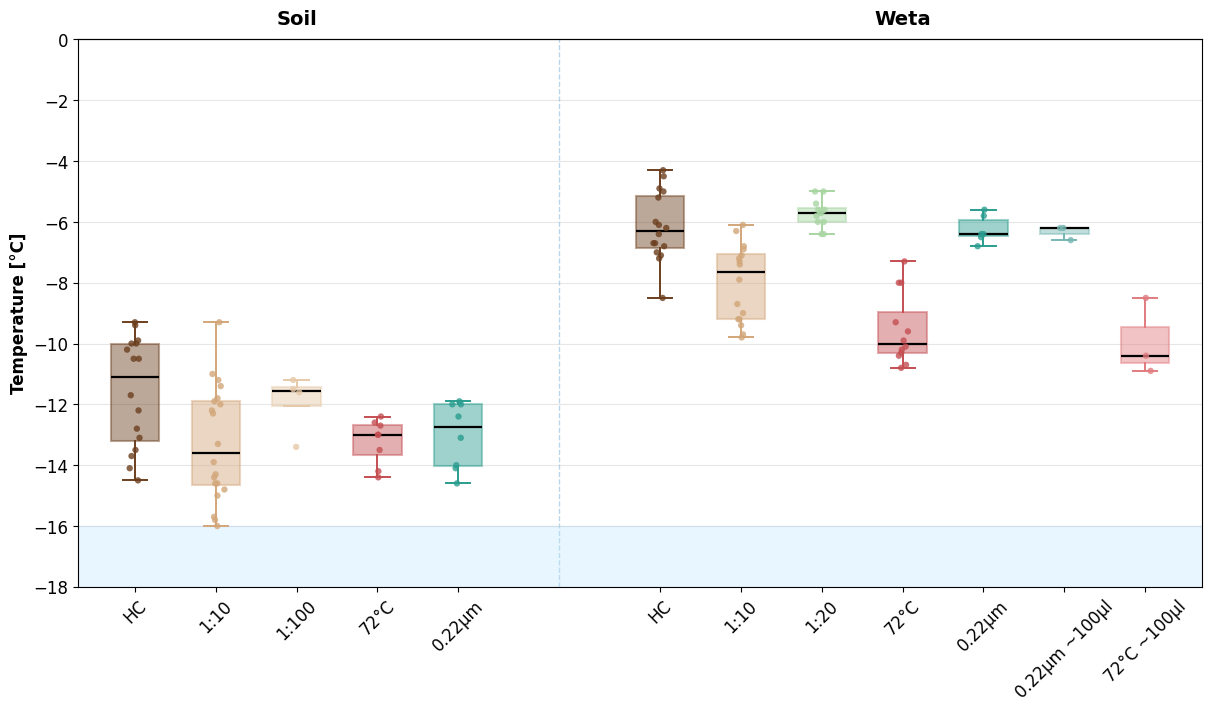

(<Figure size 1200x700 with 1 Axes>, <Axes: ylabel='Temperature [°C]'>)

In [2]:
# ============================================================
# Group repeated channels by treatment
# and separate into Soil and Weta sections
# ============================================================

TC_1_4 = ["TC1", "TC2", "TC3", "TC4"]
TC_5_8 = ["TC5", "TC6", "TC7", "TC8"]
TC_9_12 = ["TC9", "TC10", "TC11", "TC12"]
TC_9_10 = ["TC9", "TC10"]


# Colors are keyed by the boxplot label.
# Since the same label may appear in both Soil and Weta sections,
# the same treatment gets the same color in both sections.
TREATMENT_COLORS = {
    "HC": "#6B3E1E",            # dark brown
    "1:10": "#D2A679",          # light brown
    "1:20": "#A8D5A2",          # light green
    "1:100": "#E6C9A8",         # very light brown

    "72°C": "#C44E52",          # red
    "0.22µm": "#2A9D8F",        # teal

    "0.22µm ~100µl": "#76B7B2",  # light teal
    "72°C ~100µl": "#E07B7F",  # light red
}


plot_sections = [
    {
        "label": "Soil",
        "gap_after": 1.5,
        "plots": [
            combined(
                "HC",
                {
                    "EJ01A1": TC_1_4,
                    "EJ01A2": TC_1_4,
                    "EJ01A3": TC_1_4,
                    "EJ01A4": TC_1_4,
                },
            ),

            combined(
                "1:10",
                {
                    "EJ01A1": TC_5_8,
                    "EJ01A2": TC_5_8,
                    "EJ01A3": TC_5_8,
                    "EJ01A4": TC_5_8,

                    # EJ02A2 also contains SF Soil 1:10 in TC1–TC4
                    "EJ02A2": TC_1_4,
                },
            ),

            combined(
                "1:100",
                {
                    # EJ02A1 contains SF Soil 1:100 in TC1–TC4
                    "EJ02A1": TC_1_4,
                },
            ),

            combined(
                "72°C",
                {
                    "EJ02A1": TC_5_8,
                    "EJ02A2": TC_5_8,
                },
            ),

            combined(
                "0.22µm",
                {
                    "EJ02A1": TC_9_12,
                    "EJ02A2": TC_9_12,
                },
            ),
        ],
    },

    {
        "label": "Weta",
        "gap_after": 1.5,
        "plots": [
            combined(
                "HC",
                {
                    "EJ01A1": TC_9_12,
                    "EJ01A2": TC_9_12,
                    "EJ01A3": TC_9_12,
                    "EJ01A4": TC_9_12,
                },
            ),

            combined(
                "1:10",
                {
                    "EJ01A1": ["TC13", "TC14", "TC15", "TC16"],
                    "EJ01A2": ["TC13", "TC14", "TC15", "TC16"],
                    "EJ01A3": ["TC13", "TC14", "TC15", "TC16"],
                    "EJ01A4": ["TC13", "TC14", "TC15", "TC16"],
                },
            ),

            combined(
                "1:20",
                {
                    "EJ03A1": TC_1_4,
                    "EJ03A2": TC_1_4,
                    "EJ03A3": TC_1_4,
                },
            ),

            combined(
                "72°C",
                {
                    "EJ03A1": TC_5_8,
                    "EJ03A2": TC_5_8,
                    "EJ03A3": TC_5_8,
                },
            ),

            combined(
                "0.22µm",
                {
                    "EJ03A1": TC_9_10,
                    "EJ03A2": TC_9_10,
                    "EJ03A3": TC_9_10,
                },
            ),

            combined(
                "0.22µm ~100µl",
                {
                    "EJ03A1": ["TC11"],
                    "EJ03A2": ["TC11"],
                    "EJ03A3": ["TC11"],
                },
            ),

            combined(
                "72°C ~100µl",
                {
                    "EJ03A1": ["TC12"],
                    "EJ03A2": ["TC12"],
                    "EJ03A3": ["TC12"],
                },
            ),
        ],
    },
]
plot_supercooling(
    figsize = (12, 7),
    y_range=(-18, 0),
    x_label_rotation=45,
    tick_label_size=12,
    group_label_size=14,
    axis_label_size=12,
    plot_sections=plot_sections,
    treatment_colors=TREATMENT_COLORS,
    input_path=input_path,
    output_path=output_path,
    show_legend=False,
    title=None
)